In [1]:
# ============================================================
# AI vs Human Text Detection
# Install Required Libraries
# ============================================================

!pip install -q transformers datasets accelerate
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [3]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import torch
import torchvision
import datasets
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import random

In [4]:
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

Transformers: 5.0.0
Datasets: 4.8.5
Torch: 2.10.0+cu128
TorchVision: 0.25.0+cu128


In [5]:
# ============================================================
# Set Random Seeds
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed Set Successfully")

Seed Set Successfully


In [6]:
# ==========================================
# Check GPU Availability
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU Name: Tesla T4


In [7]:
# ============================================================
# Load AI Text Detection Dataset
# ============================================================

dataset = load_dataset(
    "artem9k/ai-text-detection-pile"
)

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007-bc5952582e004d(…):   0%|          | 0.00/758M [00:00<?, ?B/s]

data/train-00001-of-00007-71c80017bc45f3(…):   0%|          | 0.00/318M [00:00<?, ?B/s]

data/train-00002-of-00007-ee2d43f396e78f(…):   0%|          | 0.00/125M [00:00<?, ?B/s]

data/train-00003-of-00007-529931154b42b5(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00004-of-00007-b269dc49374a2c(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00005-of-00007-3dce5e05ddbad7(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00006-of-00007-3d8a471ba0cf1c(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1392522 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'id', 'text'],
        num_rows: 1392522
    })
})


In [8]:
# ============================================================
# Convert Dataset to Pandas DataFrame
# ============================================================

df = dataset["train"].to_pandas()
print("Shape:", df.shape)
df.head()

Shape: (1392522, 3)


,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essa...
1,human,1,20+ Social Media Post Ideas to Radically Simpl...
2,human,2,2022 Russian Invasion of Ukraine in Global Med...
3,human,3,533 U.S. 27 (2001) Kyllo v. United States: The...
4,human,4,A Charles Schwab Corporation Case Essay\n\nCha...


In [9]:
# ============================================================
# Dataset Exploration
# ============================================================

print(df.columns)
print("\nSource Distribution:")
print(df["source"].value_counts())

Index(['source', 'id', 'text'], dtype='object')

Source Distribution:
source
human    1028146
ai        364376
Name: count, dtype: int64


In [10]:
# ============================================================
# Convert Labels to Numeric Format
# ============================================================
# human -> 0
# ai -> 1

label_map = {"human": 0, "ai": 1}
df["label"] = df["source"].map(label_map)
print(df["label"].value_counts())

label
0    1028146
1     364376
Name: count, dtype: int64


In [11]:
# ============================================================
# Create Balanced Dataset
# ============================================================

human_df = df[df["label"] == 0].sample(30000, random_state=SEED)

ai_df = df[df["label"] == 1].sample(30000, random_state=SEED)

balanced_df = pd.concat([human_df, ai_df])

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(balanced_df.shape)

print(balanced_df["label"].value_counts())

(60000, 4)
label
0    30000
1    30000
Name: count, dtype: int64


In [12]:
# ============================================================
# Basic Text Cleaning
# ============================================================

balanced_df = balanced_df.dropna(subset=["text"])

balanced_df["text"] = (balanced_df["text"].astype(str).str.strip())

balanced_df = balanced_df[balanced_df["text"].str.len() > 0]

balanced_df = balanced_df[balanced_df["text"].apply(
        lambda x: len(x.split()) > 20
    )]

balanced_df = balanced_df.reset_index(drop=True)

print("Final Shape:")
print(balanced_df.shape)

Final Shape:
(59111, 4)


In [13]:
# ============================================================
# Train Validation Test Split
# ============================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    balanced_df["text"],
    balanced_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=balanced_df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

Training Samples: 47288
Validation Samples: 5911
Test Samples: 5912


In [14]:
#-------------------------------------------
# LOAD TOKENIZER
#-------------------------------------------
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
print(type(tokenizer))
print(tokenizer.name_or_path)

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
distilbert-base-uncased


In [16]:
# ============================================================
# Custom PyTorch Dataset
# ============================================================

MAX_LENGTH = 128
class AITextDataset(Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer
    ):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(
                    self.labels[idx],
                    dtype=torch.long
                )
        }

In [17]:
# ==========================================
# Creating dataset objects
# ==========================================

train_dataset = AITextDataset(
    train_texts,
    train_labels,
    tokenizer
)

val_dataset = AITextDataset(
    val_texts,
    val_labels,
    tokenizer
)

test_dataset = AITextDataset(
    test_texts,
    test_labels,
    tokenizer
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

47288
5911
5912


In [18]:
# ==========================================
# Creating Data Loaders
# ==========================================
BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
# ============================================================
# Verify DataLoader
# ============================================================

batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [20]:
# ==========================================
# Load DistilBert Model
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [21]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

print("Optimizer Ready")

Optimizer Ready


In [22]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return (
        avg_loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [24]:
# ==========================================
# Training Loop
# ==========================================

EPOCHS = 2

train_losses = []
val_losses = []

best_f1 = 0
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader)
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix(
            {"loss": loss.item()}
        )

    avg_train_loss = (total_train_loss / len(train_loader))
    train_losses.append(avg_train_loss)

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = evaluate_model(
        model,
        val_loader
    )

    val_losses.append(val_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_acc:.4f}")

    print(f"Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_distilbert_ai_detector.pt")
        print("Best model saved.")


Epoch 1/2


100%|██████████| 2956/2956 [10:14<00:00,  4.81it/s, loss=0.0645] 


Train Loss: 0.1490
Val Loss: 0.1575
Val Accuracy: 0.9330
Val F1: 0.9359
Best model saved.

Epoch 2/2


100%|██████████| 2956/2956 [10:23<00:00,  4.74it/s, loss=0.0108]  


Train Loss: 0.0584
Val Loss: 0.1229
Val Accuracy: 0.9599
Val F1: 0.9603
Best model saved.


In [25]:
# ==========================================
# Load Best Model
# ==========================================

model.load_state_dict(
    torch.load(
        "best_distilbert_ai_detector.pt"
    )
)
print("Best Model Loaded")

Best Model Loaded


In [26]:
torch.save(
    model.state_dict(),
    "best_distilbert_ai_detector.pt"
)

In [27]:
SAVE_PATH = "ai_text_detector_model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ai_text_detector_model/tokenizer_config.json',
 'ai_text_detector_model/tokenizer.json')

In [28]:
# ==========================================
# Model Evaluation
# ==========================================

test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(model, test_loader)

print("\nTEST RESULTS")

print("Accuracy :", test_acc)
print(f"Loss: {test_loss:.4f}")
print("Precision:", test_prec)
print("Recall   :", test_rec)
print("F1 Score :", test_f1)


TEST RESULTS
Accuracy : 0.9523004059539919
Loss: 0.1439
Precision: 0.9223145780051151
Recall   : 0.9866621067031464
F1 Score : 0.9534038334434898


In [29]:
# ==========================================
# Generate Predictions
# ==========================================

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

100%|██████████| 370/370 [00:27<00:00, 13.36it/s]


In [30]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(all_labels, all_preds, target_names=["Human", "AI"]))

              precision    recall  f1-score   support

       Human       0.99      0.92      0.95      2988
          AI       0.92      0.99      0.95      2924

    accuracy                           0.95      5912
   macro avg       0.95      0.95      0.95      5912
weighted avg       0.95      0.95      0.95      5912



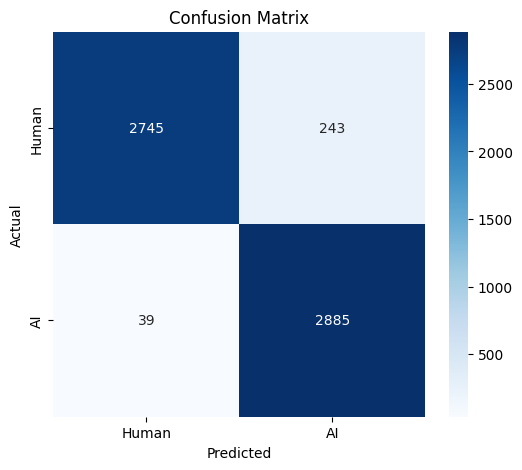

In [31]:
#===============================================
# Confusion Matrix
#===============================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [37]:
#======================================================
#Predictions On Custom Data
#======================================================
import torch
import torch.nn.functional as F

def predict_text(text):

    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = F.softmax(
            outputs.logits,
            dim=1
        )

    human_prob = probs[0][0].item()
    ai_prob = probs[0][1].item()

    prediction = torch.argmax(
        probs,
        dim=1
    ).item()

    label = (
        "AI Generated"
        if prediction == 1
        else "Human Written"
    )

    confidence = max(
        human_prob,
        ai_prob
    ) * 100

    print("="*60)
    print("Prediction :", label)
    print(f"Confidence : {confidence:.2f}%")
    print(f"Human Prob : {human_prob:.4f}")
    print(f"AI Prob    : {ai_prob:.4f}")
    print("="*60)

    return {
        "prediction": label,
        "confidence": confidence,
        "human_prob": human_prob,
        "ai_prob": ai_prob
    }

In [38]:
human_text_1 = """
The Taj Mahal is an ivory-white marble mausoleum located in Agra, India.
It was commissioned in 1632 by the Mughal emperor Shah Jahan in memory
of his wife Mumtaz Mahal. The monument is widely regarded as one of the
finest examples of Mughal architecture and attracts millions of visitors
every year.
"""

predict_text(human_text_1)

Prediction : AI Generated
Confidence : 98.37%
Human Prob : 0.0163
AI Prob    : 0.9837


{'prediction': 'AI Generated',
 'confidence': 98.3729898929596,
 'human_prob': 0.016270125284790993,
 'ai_prob': 0.983729898929596}

In [39]:
ai_text_1 = """
Artificial intelligence is revolutionizing industries across the globe
by enabling organizations to automate processes, improve efficiency,
and gain deeper insights from data. Businesses that adopt AI-driven
strategies are often better positioned to innovate and remain competitive
in rapidly changing markets.
"""

predict_text(ai_text_1)

Prediction : AI Generated
Confidence : 87.48%
Human Prob : 0.1252
AI Prob    : 0.8748


{'prediction': 'AI Generated',
 'confidence': 87.47982382774353,
 'human_prob': 0.1252017617225647,
 'ai_prob': 0.8747982382774353}